## 1. Problem Statement
<p>
    <b>Build a deep learning model to classify chest X-ray images as Pneumonia or Normal.</b><br>
    <b>Goal: Minimize False Negatives since missing pneumonia cases is medically critical.
        


In [3]:
import tensorflow as tf
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

## 2. Dataset Overview
<h3> <ul><li>  Number of images per class </li></ul></h3>

In [4]:
train_path = r"D:\ML Projects\chest_xray\train"

class_counts = {}
for category in os.listdir(train_path):
    category_path = os.path.join(train_path,category)
    num_images = len(os.listdir(category_path))
    class_counts[category] = num_images

print(class_counts)
    

{'NORMAL': 1342, 'PNEUMONIA': 3876}


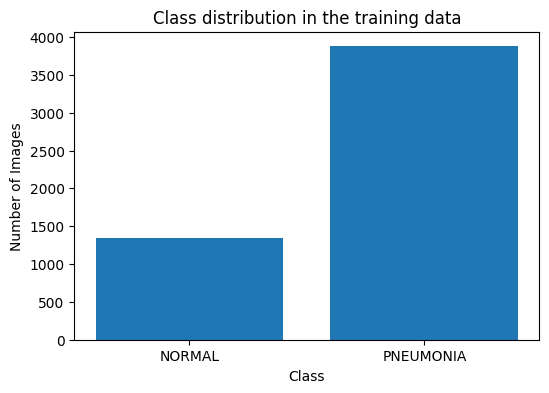

In [17]:
category = list(class_counts.keys())
counts = list(class_counts.values())

# print(category)
# print(counts)

plt.figure(figsize=(6,4))
plt.bar(category,counts)

plt.title("Class distribution in the training data")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

### Observation

<p>The dataset is <b>imbalanced</b>, with significantly more Pneumonia images than Normal images. 
<br>This may bias the model toward predicting Pneumonia more often.
    <br>Therefore, evaluation metrics such as <b>Recall</b> and <b>F1-score</b> are more important than accuracy alone.


In [6]:
import random
import matplotlib.image as mpimg

normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

# Randomly selecting the 5 samples from Normal and Pneumonia files.
normal_images = random.sample(os.listdir(normal_path),5)
pneumonia_images = random.sample(os.listdir(pneumonia_path),5)



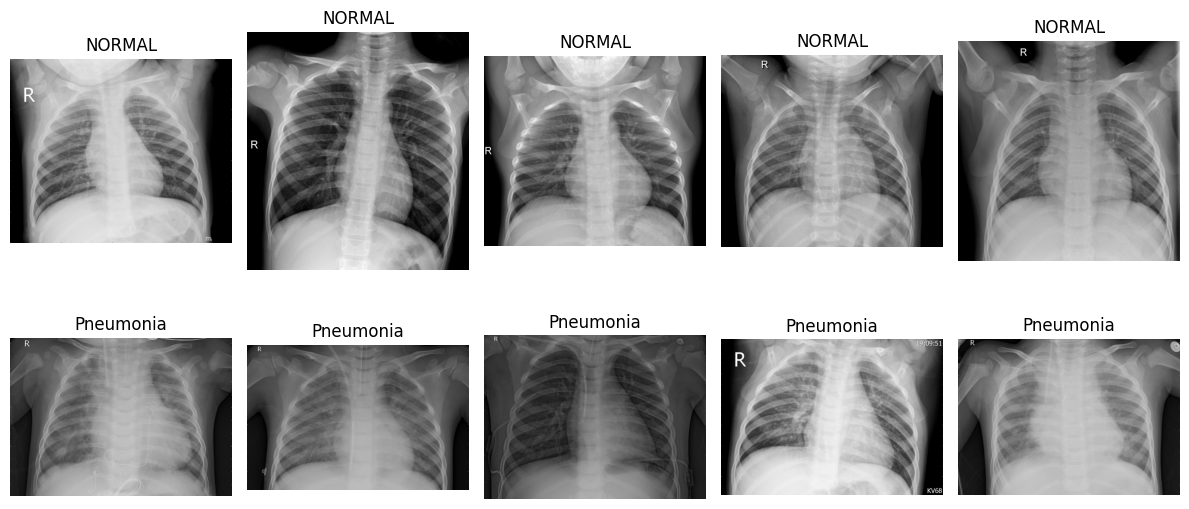

In [10]:
plt.figure(figsize =(12,6))

# Plotting of the Normal images 
for i, image in enumerate(normal_images):
    img_path = os.path.join(normal_path, image)
    img = mpimg.imread(img_path)
    
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title("NORMAL")
    plt.axis('off')
    
#Plotting of the Pneumonia images

for i, image in enumerate(pneumonia_images):
    img_path= os.path.join(pneumonia_path,image)
    img = mpimg.imread(img_path)
    
    plt.subplot(2,5,i+6)
    plt.imshow(img, cmap='grey')
    plt.title("Pneumonia")
    plt.axis('off')
    
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

Before training the CNN model, the images are preprocessed to:

• Normalize pixel values  
• Resize images to match model input shape  
• Apply data augmentation to improve generalization  
• Create structured training, validation, and test generators  

These steps help improve model stability and prevent overfitting.


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_gen = ImageDataGenerator(
    rescale= 1./255,
    rotation_range = 15,
    zoom_range = 0.1,
    horizontal_flip = True
)


### Image Data Normaization

We are normalizing our image that has dimensions of pixel from 256*256 to in range [0,1], because Neaural Networks trains better when values range lies between 0 to 1.

In [19]:
val_gen = ImageDataGenerator(rescale=1./255)

### Why Data Augmentation?

clearly dataset is imbalanced and not extremely large, that is why we are applying data augumentation here in order to 
<b><br>Increase data diversity<br>
Improve generalization<br>
Reduce overfitting

In [22]:

train_data = train_gen.flow_from_directory(
    r"D:\ML Projects\chest_xray\train",
    target_size = (224,224),
    color_mode = "grayscale",
    #color_mode = 'rgb',
    batch_size = 32,
    class_mode = "binary"    
)

val_data = val_gen.flow_from_directory(
    r"D:\ML Projects\chest_xray\val",
    target_size = (224,224),
    color_mode = "grayscale",
    #color_mode = 'rgb',
    batch_size = 32,
    class_mode = "binary"
)

test_data = val_gen.flow_from_directory(
    r"D:\ML Projects\chest_xray\test",
    target_size = (224,224),
    color_mode = "grayscale", # 
    #color_mode = 'rgb',
    batch_size = 32,
    class_mode = "binary",
    shuffle = False
    
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [14]:
print(train_data.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


### Preprocessing Summary

• Images resized to 224×224  
• Pixel values normalized to [0,1]  
• Data augmentation applied only to training set  
• Binary classification setup (Normal vs Pneumonia)



<h2>Builiding CNN from Scratch </h2>

In [15]:
from tensorflow.keras import layers,models

In [23]:
train_data = train_gen.flow_from_directory(
    r"D:\ML Projects\chest_xray\train",
    target_size = (224,224),
    #color_mode = "grayscale",
    color_mode = 'rgb',
    batch_size = 32,
    class_mode = "binary"    
)

val_data = val_gen.flow_from_directory(
    r"D:\ML Projects\chest_xray\val",
    target_size = (224,224),
    #color_mode = "grayscale",
    color_mode = 'rgb',
    batch_size = 32,
    class_mode = "binary"
)

test_data = val_gen.flow_from_directory(
    r"D:\ML Projects\chest_xray\test",
    target_size = (224,224),
    #color_mode = "grayscale", # 
    color_mode = 'rgb',
    batch_size = 32,
    class_mode = "binary",
    shuffle = False
    
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [18]:
model = models.Sequential([
    layers.Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation = 'relu',
        padding = 'same',
        input_shape = (224,224,1)
    ),
    layers.MaxPooling2D(2,2),

    #Block 2
    layers.Conv2D(
        filters = 64,
        kernel_size = (3,3),
        activation = 'relu',
        padding = 'same'
    ),
    layers.MaxPooling2D(2,2),

    #Block 3 
    layers.Conv2D(
        filters = 128,
        kernel_size = (3,3),
        activation = 'relu',
        padding = 'same'
    ),
    layers.MaxPooling2D(2,2),

    #Classifier 
    layers.Flatten(),
    layers.Dense(128,activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')

])
                  
                  

D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy', tf.keras.metrics.Recall()]
)

In [19]:
history = model.fit(
    train_data,
    epochs = 15,
    validation_data = val_data
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.8286 - loss: 0.3760 - recall: 0.9363 - val_accuracy: 0.6875 - val_loss: 0.6390 - val_recall: 1.0000
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 934ms/step - accuracy: 0.9032 - loss: 0.2356 - recall: 0.9440 - val_accuracy: 0.7500 - val_loss: 0.5806 - val_recall: 1.0000
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.9160 - loss: 0.2212 - recall: 0.9492 - val_accuracy: 0.8125 - val_loss: 0.3822 - val_recall: 1.0000
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 657ms/step - accuracy: 0.9239 - loss: 0.2025 - recall: 0.9559 - val_accuracy: 0.8750 - val_loss: 0.4347 - val_recall: 1.0000
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.9342 - loss: 0.1774 - recall: 0.9574 - val_accuracy: 0.6250 - val_loss: 0.9575 - val_recall: 1.0000
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 621ms/step - accuracy: 0.9383 - loss: 0.1708 - recall: 0.9613 - val_accuracy: 0.6875 - val_loss: 0.5336 - va

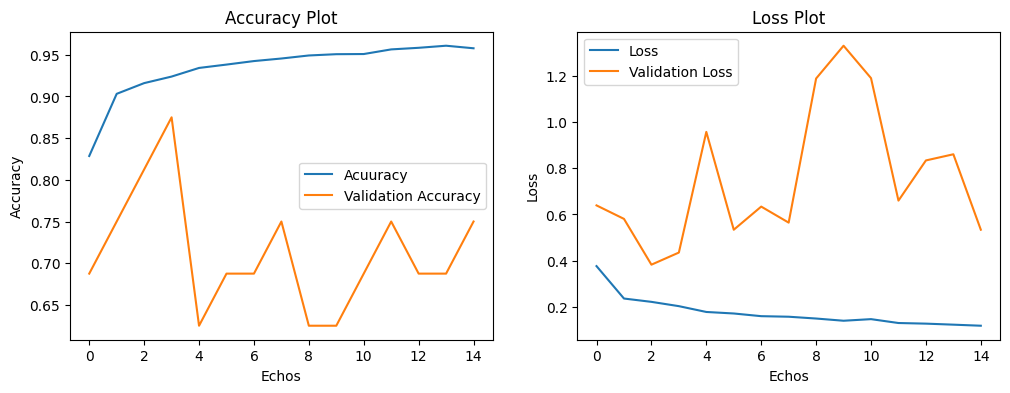

In [24]:
plt.figure(figsize = (12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Acuuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Echos")
plt.legend()
plt.title("Accuracy Plot")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = "Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Echos")
plt.legend()
plt.title("Loss Plot")

plt.show()

In [25]:
test_loss, test_accuracy, test_recall = model.evaluate(test_data)

print("Test Accuracy", test_accuracy)
print("Test Recall", test_recall)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 448ms/step - accuracy: 0.7692 - loss: 0.7985 - recall: 0.9974
Test Accuracy 0.7692307829856873
Test Recall 0.9974358677864075


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [27]:
y_pred = model.predict(test_data)
y_pred = (y_pred >0.5).astype(int)

cm = confusion_matrix(test_data.classes, y_pred)

print(cm)
print(classification_report(test_data.classes, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step
[[ 91 143]
 [  1 389]]
              precision    recall  f1-score   support

           0       0.99      0.39      0.56       234
           1       0.73      1.00      0.84       390

    accuracy                           0.77       624
   macro avg       0.86      0.69      0.70       624
weighted avg       0.83      0.77      0.74       624



In [29]:
tf.keras.backend.clear_session()

In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


<h2>MobileNetV2 Transfer Learning </h2>

In [22]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


In [23]:
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation = 'sigmoid')
])


In [24]:
transfer_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy', tf.keras.metrics.Recall()]
)

In [43]:
tranfer_history = transfer_model.fit(
    train_data,
    validation_data = val_data,
    epochs = 10   
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9084 - loss: 0.2141 - recall_1: 0.9468 - val_accuracy: 0.8125 - val_loss: 0.4216 - val_recall_1: 1.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 700ms/step - accuracy: 0.9511 - loss: 0.1315 - recall_1: 0.9695 - val_accuracy: 0.8125 - val_loss: 0.3662 - val_recall_1: 1.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 118s 725ms/step - accuracy: 0.9511 - loss: 0.1209 - recall_1: 0.9659 - val_accuracy: 0.8750 - val_loss: 0.2946 - val_recall_1: 1.0000
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9567 - loss: 0.1114 - recall_1: 0.9698 - val_accuracy: 0.8125 - val_loss: 0.3996 - val_recall_1: 1.0000
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 713ms/step - accuracy: 0.9630 - loss: 0.0998 - recall_1: 0.9763 - val_accuracy: 0.8750 - val_loss: 0.1980 - val_recall_1: 1.0000
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 696ms/step - accuracy: 0.9647 - loss: 0.0908 - recall_1: 0.9773 - val_accuracy: 0.8750 - va

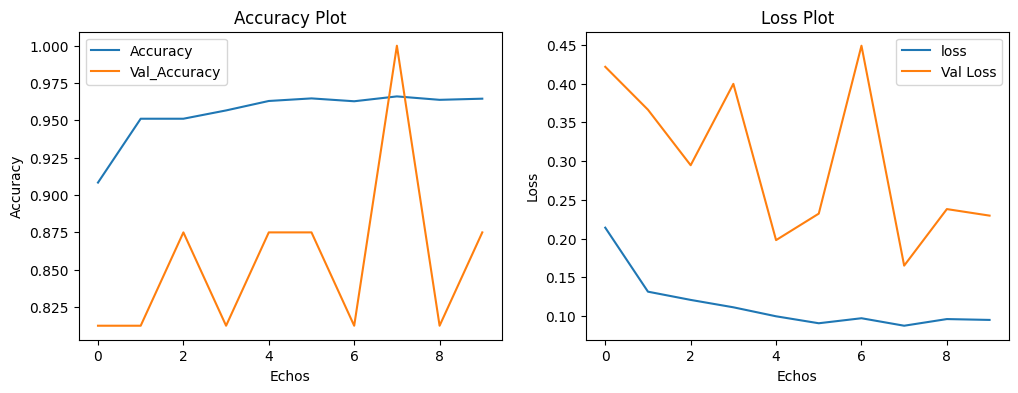

In [46]:
plt.figure(figsize = (12,4))

plt.subplot(1,2,1)
plt.plot(tranfer_history.history['accuracy'], label = "Accuracy")
plt.plot(tranfer_history.history['val_accuracy'], label = "Val_Accuracy")
plt.title("Accuracy Plot")
plt.xlabel("Echos")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1,2,2)
plt.plot(tranfer_history.history['loss'], label = 'loss')
plt.plot(tranfer_history.history['val_loss'], label = 'Val Loss')
plt.title("Loss Plot")
plt.xlabel("Echos")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [48]:
transfer_model.evaluate(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 752ms/step - accuracy: 0.8782 - loss: 0.3076 - recall_1: 0.9667


[0.3076043128967285, 0.8782051205635071, 0.9666666388511658]

In [25]:
from sklearn.metrics import confusion_matrix, classification_report


In [51]:
transfer_pred = transfer_model.predict(test_data)
transfer_pred = (transfer_pred >0.3).astype(int)

cm = confusion_matrix(test_data.classes, transfer_pred)
print('''Confusion Matrix 
        [TP  FP]
        [FN  TN]
      ''', cm)

classification_rep = classification_report(test_data.classes, transfer_pred)
print("\n",classification_rep)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 448ms/step
Confusion Matrix 
        [TP  FP]
        [FN  TN]
       [[158  76]
 [  9 381]]

               precision    recall  f1-score   support

           0       0.95      0.68      0.79       234
           1       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.83      0.84       624
weighted avg       0.88      0.86      0.86       624



In [52]:
transfer_pred = transfer_model.predict(test_data)
transfer_pred = (transfer_pred >0.5).astype(int)

cm = confusion_matrix(test_data.classes, transfer_pred)
print('''Confusion Matrix 
        [TP  FP]
        [FN  TN]
      ''', cm)

classification_rep = classification_report(test_data.classes, transfer_pred)
print("\n",classification_rep)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 453ms/step
Confusion Matrix 
        [TP  FP]
        [FN  TN]
       [[171  63]
 [ 13 377]]

               precision    recall  f1-score   support

           0       0.93      0.73      0.82       234
           1       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



In [54]:
len(base_model.layers)

154

<h2>Fine Tunning top 124 layers</h2>

In [26]:

for layer in base_model.layers[-30:]:
    layer.trainable = True


In [60]:
transfer_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-5),
    loss = 'binary_crossentropy', 
    metrics = ['accuracy', tf.keras.metrics.Recall()]
)

In [61]:
history_tf = transfer_model.fit(
    train_data,
    validation_data = val_data,
    epochs = 5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 156s 889ms/step - accuracy: 0.9187 - loss: 0.2012 - recall_2: 0.9277 - val_accuracy: 0.8125 - val_loss: 0.2590 - val_recall_2: 1.0000
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 874ms/step - accuracy: 0.9519 - loss: 0.1253 - recall_2: 0.9677 - val_accuracy: 0.8125 - val_loss: 0.3559 - val_recall_2: 1.0000
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 858ms/step - accuracy: 0.9628 - loss: 0.0992 - recall_2: 0.9742 - val_accuracy: 0.8125 - val_loss: 0.4316 - val_recall_2: 1.0000
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 864ms/step - accuracy: 0.9668 - loss: 0.0912 - recall_2: 0.9783 - val_accuracy: 0.8125 - val_loss: 0.5230 - val_recall_2: 1.0000
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 834ms/step - accuracy: 0.9689 - loss: 0.0818 - recall_2: 0.9796 - val_accuracy: 0.8125 - val_loss: 0.5018 - val_recall_2: 1.0000


In [63]:
tr_accuracy, tr_loss, tr_recall = transfer_model.evaluate(test_data)
print("Accuracy", tr_accuracy)
print("Loss", tr_loss)
print("Recall", tr_recall)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 520ms/step - accuracy: 0.8686 - loss: 0.4675 - recall_2: 0.9718
Accuracy 0.46749788522720337
Loss 0.8685897588729858
Recall 0.971794843673706


<h3> Fine Tunnng thresholds </h3>

In [65]:
tr_pred = transfer_model.predict(test_data)
tr_pred = (tr_pred>0.5).astype(int)

cm = confusion_matrix(test_data.classes, tr_pred)
print(" [[TN FP) [FN TP]]", cm)

tr_classification = classification_report(test_data.classes, tr_pred)
print(tr_classification)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 566ms/step
 [[TN FP) [FN TP]] [[163  71]
 [ 11 379]]
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       234
           1       0.84      0.97      0.90       390

    accuracy                           0.87       624
   macro avg       0.89      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624



In [66]:
tr_pred = transfer_model.predict(test_data)
tr_pred = (tr_pred>0.3).astype(int)

cm = confusion_matrix(test_data.classes, tr_pred)
print(" [[TN FP) [FN TP]]", cm)

tr_classification = classification_report(test_data.classes, tr_pred)
print(tr_classification)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 809ms/step
 [[TN FP) [FN TP]] [[140  94]
 [  6 384]]
              precision    recall  f1-score   support

           0       0.96      0.60      0.74       234
           1       0.80      0.98      0.88       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



In [2]:
import os
print(os.getcwd())

D:\ML Projects\Medical-CNN-Pneumonia-Detection\Notebook


In [27]:
transfer_model.save("mobilenet_finetuned.h5")